# Model V4 — AR(1) with Annual Cycle, Per-Region New Year Effect, Full Reset, and Partial Pooling Alpha

**Likelihood:**
$$y_{i,1} \sim \mathcal{N}(\mu_{i,1},\, \tau_i)$$
$$y_{i,t} \sim \mathcal{N}\\Big(\mu_{i,t} + \phi\,(y_{i,t-1} - \mu_{i,t-1}),\, \tau_i\Big), \quad t = 2,\ldots,T$$

**Mean function (same structure as V3):**
$$\mu_{i,t} = \alpha_i + \beta_i \cos\\Big(\frac{2\pi t}{52}\Big) + \gamma_i \sin\\Big(\frac{2\pi t}{52}\Big) + $$
$$\delta_{\text{pre},i}\, \mathbb{1}(t\bmod 52 = 0) + \delta_{\text{mid},i}\, \mathbb{1}(t\bmod 52 = 1) + \delta_{\text{post},i}\, \mathbb{1}(t\bmod 52 = 2) + $$
$$\sigma_{\text{pre}}\, \mathbb{1}(t = 86, i=\text{mid west}) + \sigma_{\text{mid}}\, \mathbb{1}(t = 87, i=\text{mid west}) + \sigma_{\text{post}}\, \mathbb{1}(t = 88, i=\text{mid west})$$

**Hierarchical prior on intercept:**
$$\alpha_i \sim \mathcal{N}(\mu_\alpha,\; \tau_\alpha)$$

**Other priors:**
$$\beta_i, \gamma_i, \delta_{\text{pre},i}, \delta_{\text{mid},i}, \delta_{\text{post},i} \sim \mathcal{N}(0,\, 10^3) \quad \tau_i \sim \text{Gamma}(0.001,\, 0.001) \quad \phi \sim \text{Uniform}(-1,\, 1)$$
$$\sigma_{\text{pre}},\, \sigma_{\text{mid}},\, \sigma_{\text{post}} \sim \mathcal{N}(0,\, 10^3) \quad \mu_\alpha \sim \mathcal{N}(0,\, 10^3) \quad \tau_\alpha \sim \text{Gamma}(0.001,\, 0.001)$$

**Key difference from V3:** the prior on $\alpha_i$ uses partial pooling — $\alpha_i \sim \mathcal{N}(\mu_\alpha, \tau_\alpha)$ with uninformative hyperpriors.

In [1]:
from model_helpers import *

VERSION = 'v4'
PLOT_DIR = f'../../data/models/{VERSION}/plots/'
DATA_DIR = f'../../data/models/{VERSION}/'

df_og, raw_df, regions, n_region = load_model_data(VERSION)

## Load the model parameters

In [2]:
n_weeks = df_og.shape[1] - 1
ev = build_event_indicators(n_weeks, regions)
df_mu, df_mu_lower, df_mu_upper, phi_mean = reconstruct_mu(raw_df, regions, n_weeks, ev)

## Preprocess
Transpose the og df into regions (cols) x time (weeks)

In [3]:
df_og = transpose_observed(df_og)

## Make the model estimate df
Formula
y[i,t] ~ dnorm(mu[i,t] + (phi * (y[i,t-1] - mu[i,t-1])), tau[i])

In [4]:
df_ar1 = compute_ar1_fitted(df_mu, df_og, phi_mean)
df_ar1

,HSE Dublin and Midlands,HSE Dublin and North East,HSE Dublin and South East,HSE Mid West,HSE South West,HSE West and North West
0,0.856168,0.582344,0.861417,2.549697,1.339548,1.694619
1,4.81002,2.915129,3.665299,7.225288,5.765145,7.964294
2,6.265202,4.460185,5.19937,7.266073,6.228353,8.179777
3,5.357747,3.210242,4.242348,5.285021,5.120819,6.250008
4,5.20757,2.630791,3.622421,5.846635,5.12758,7.530282
...,...,...,...,...,...,...
146,2.941318,1.948627,2.955843,7.232963,5.090926,6.671569
147,2.500115,1.717905,3.106099,5.6047,5.432534,5.29689
148,2.530866,1.769256,3.070761,5.097815,4.576514,5.835036
149,2.941013,1.913096,3.005875,5.456413,5.108406,5.347207


## Plot MU
This should look like yearly oscillations

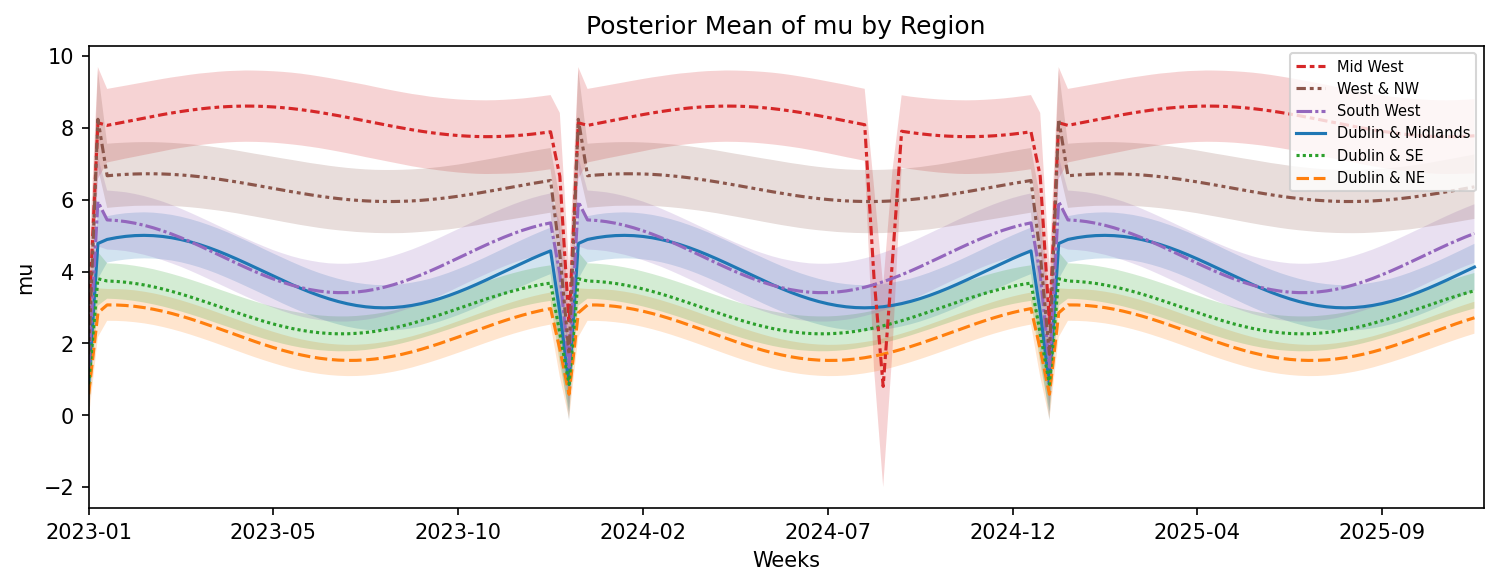

In [5]:
plot_mu(df_mu, df_mu_lower, df_mu_upper, PLOT_DIR + 'mu_fit.png')

## Plot model fit

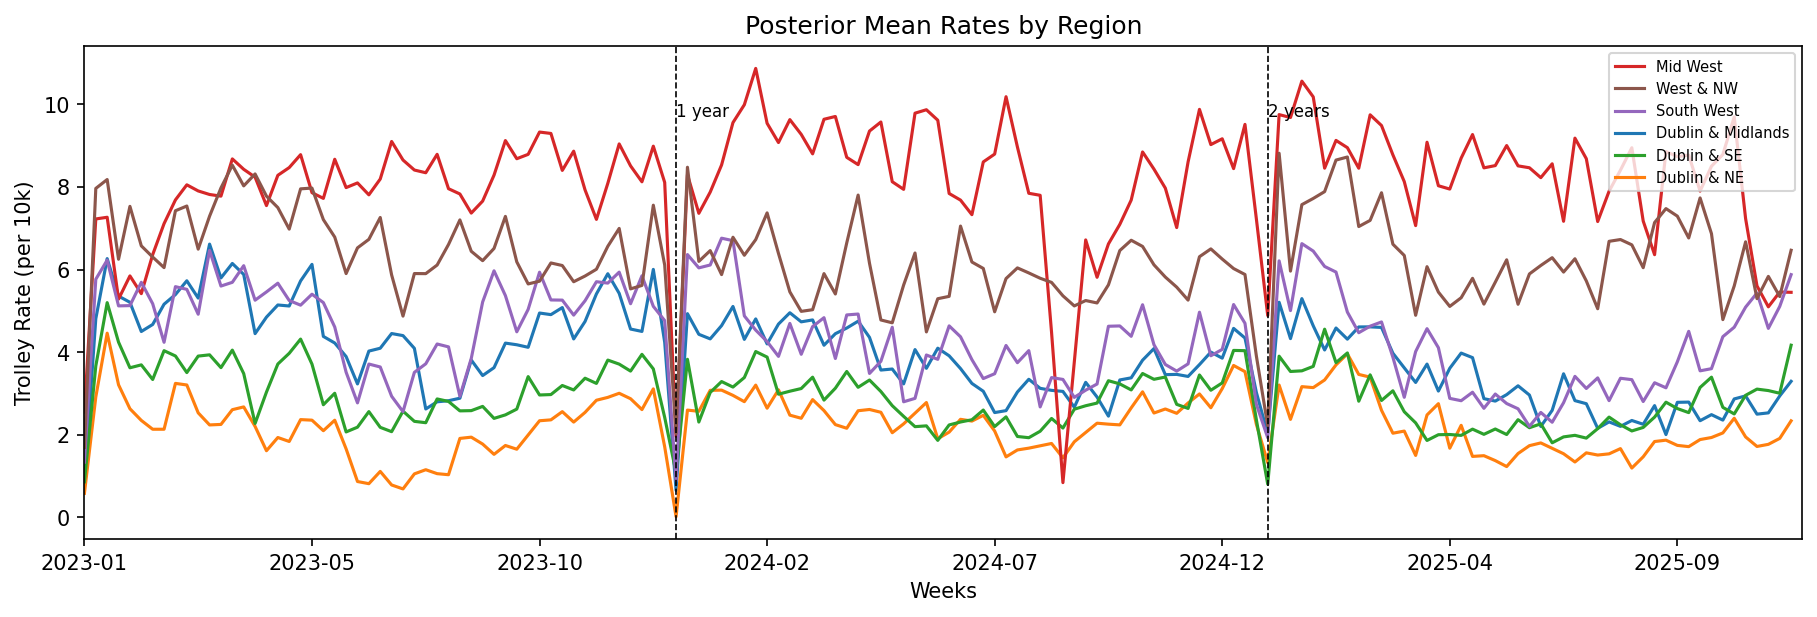

In [6]:
plot_ar1_fit(df_ar1, PLOT_DIR + 'ar1_fit.png')

## Plot the residuals

In [7]:
df_residuals, df_std_resid = compute_residuals(df_og, df_ar1)

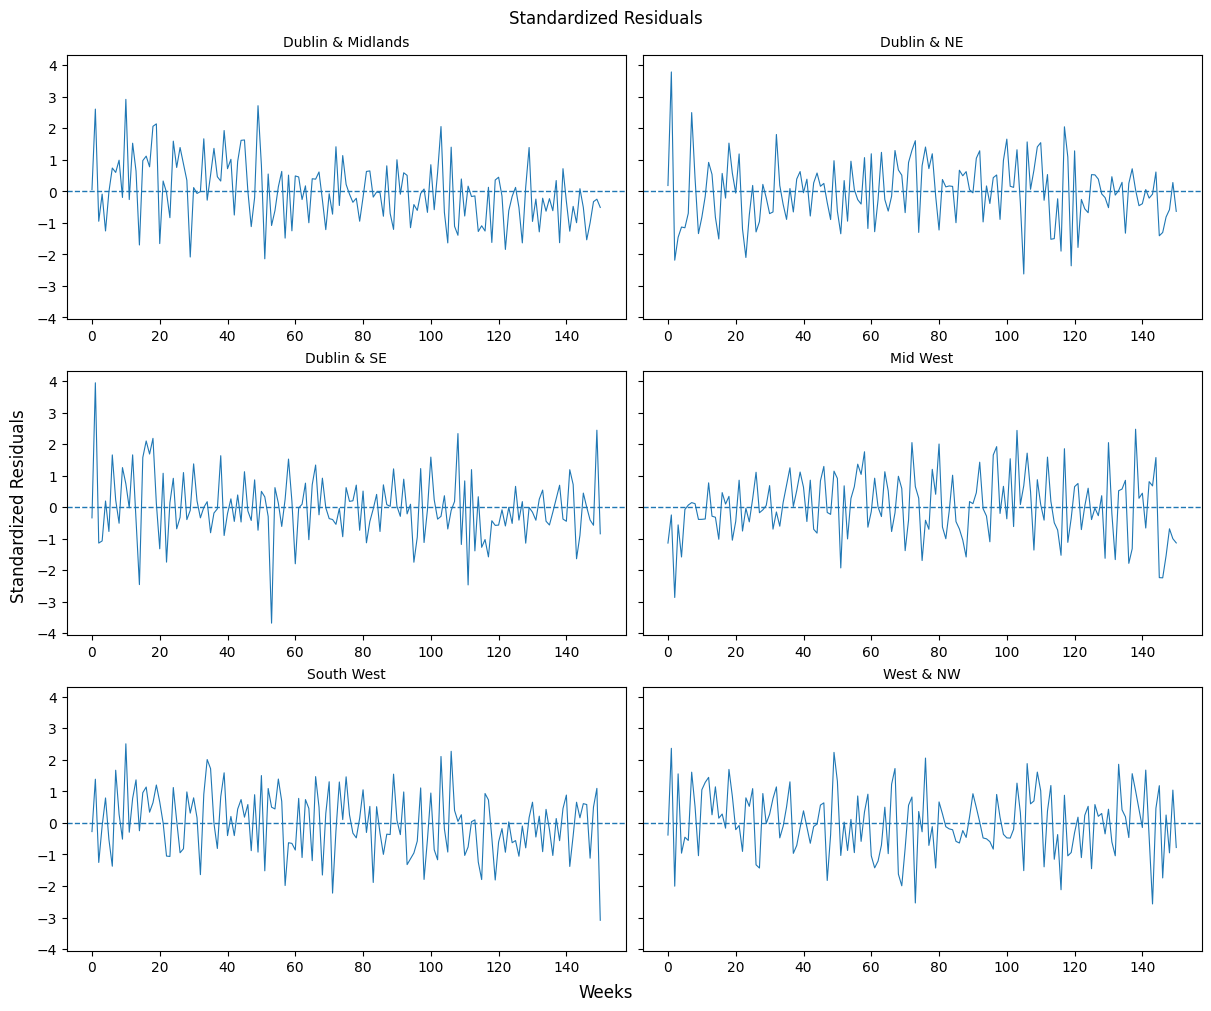

In [8]:
plot_residuals_ts(df_std_resid, PLOT_DIR + 'residuals_ts.png')

### Autocorrelation of Residuals

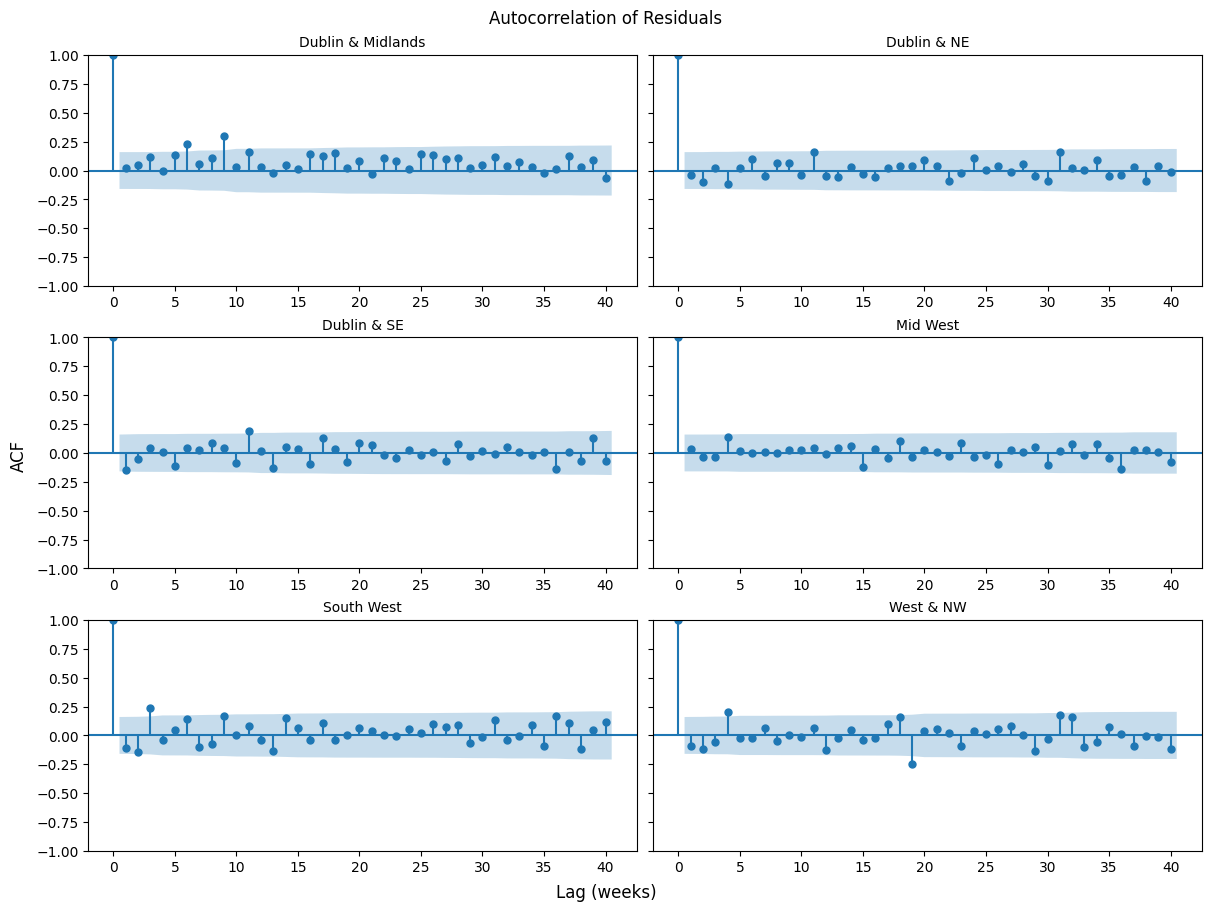

In [9]:
plot_residuals_acf(df_std_resid, PLOT_DIR + 'residuals_acf.png')

### Residuals vs Fitted

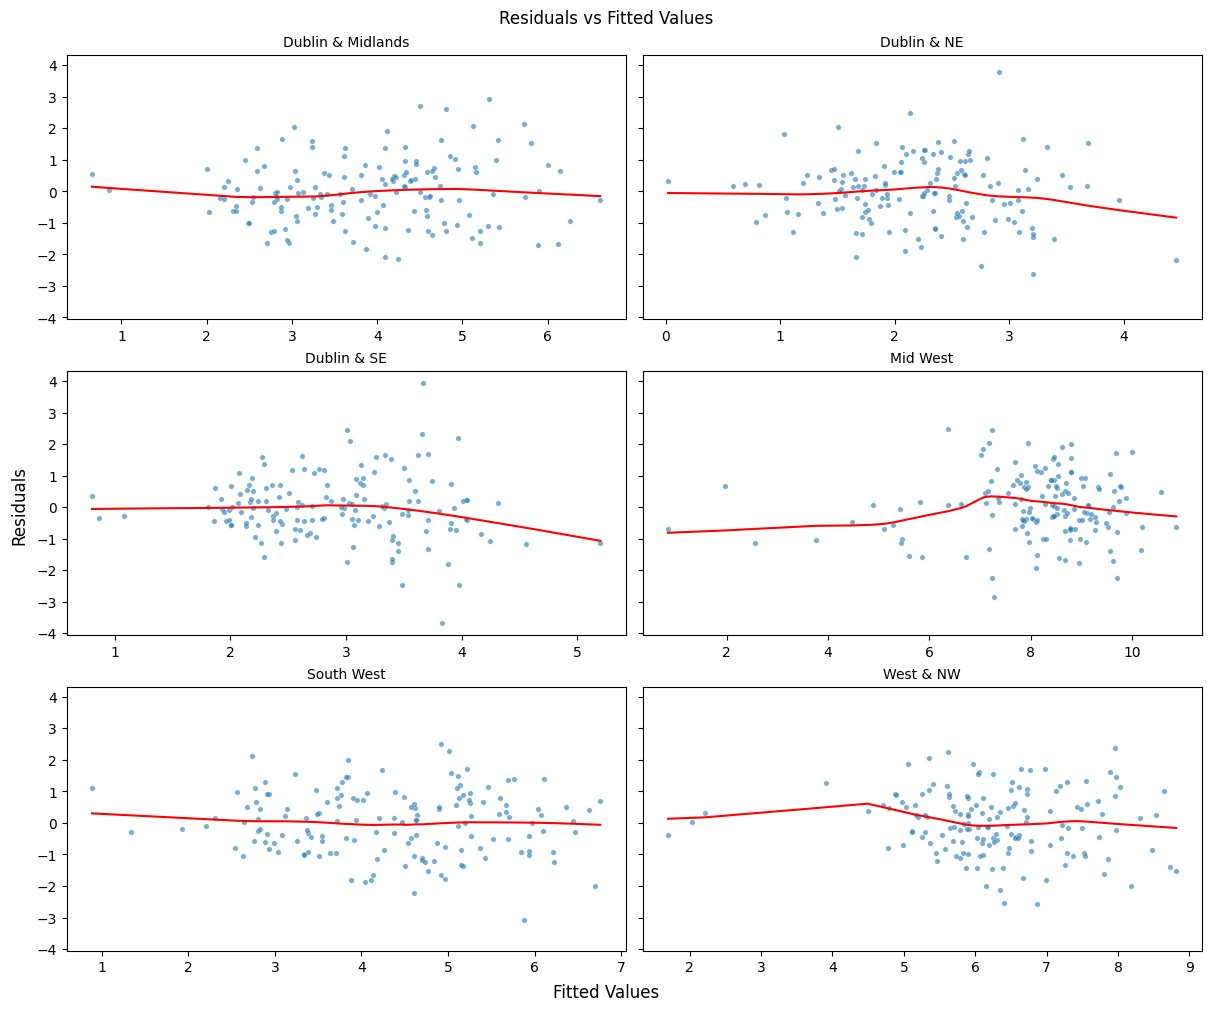

In [10]:
plot_residuals_vs_fitted(df_std_resid, df_ar1, PLOT_DIR + 'residuals_vs_fitted.png')

### QQ-Plot For Residuals

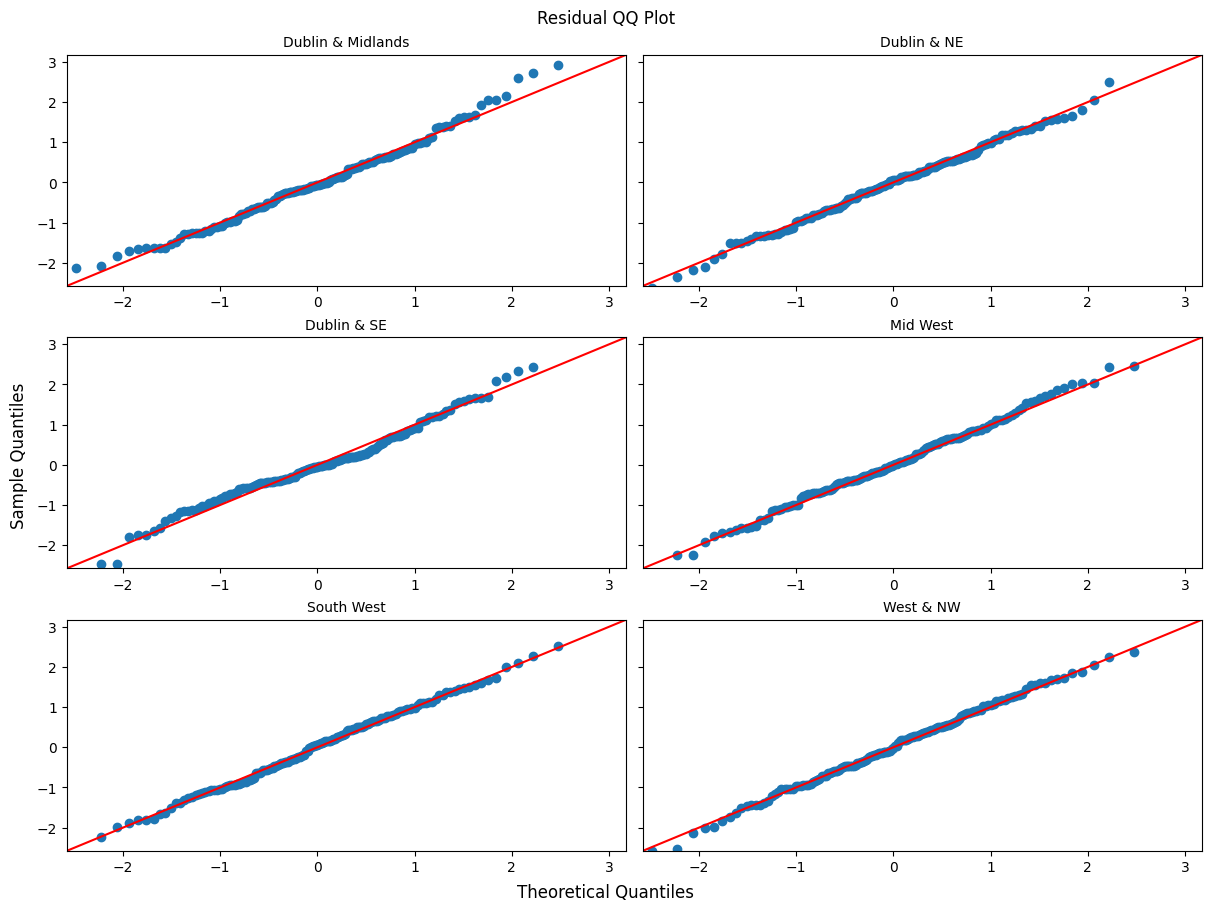

In [11]:
plot_residuals_qq(df_std_resid, PLOT_DIR + 'residuals_qq.png')

### Residual Periodogram

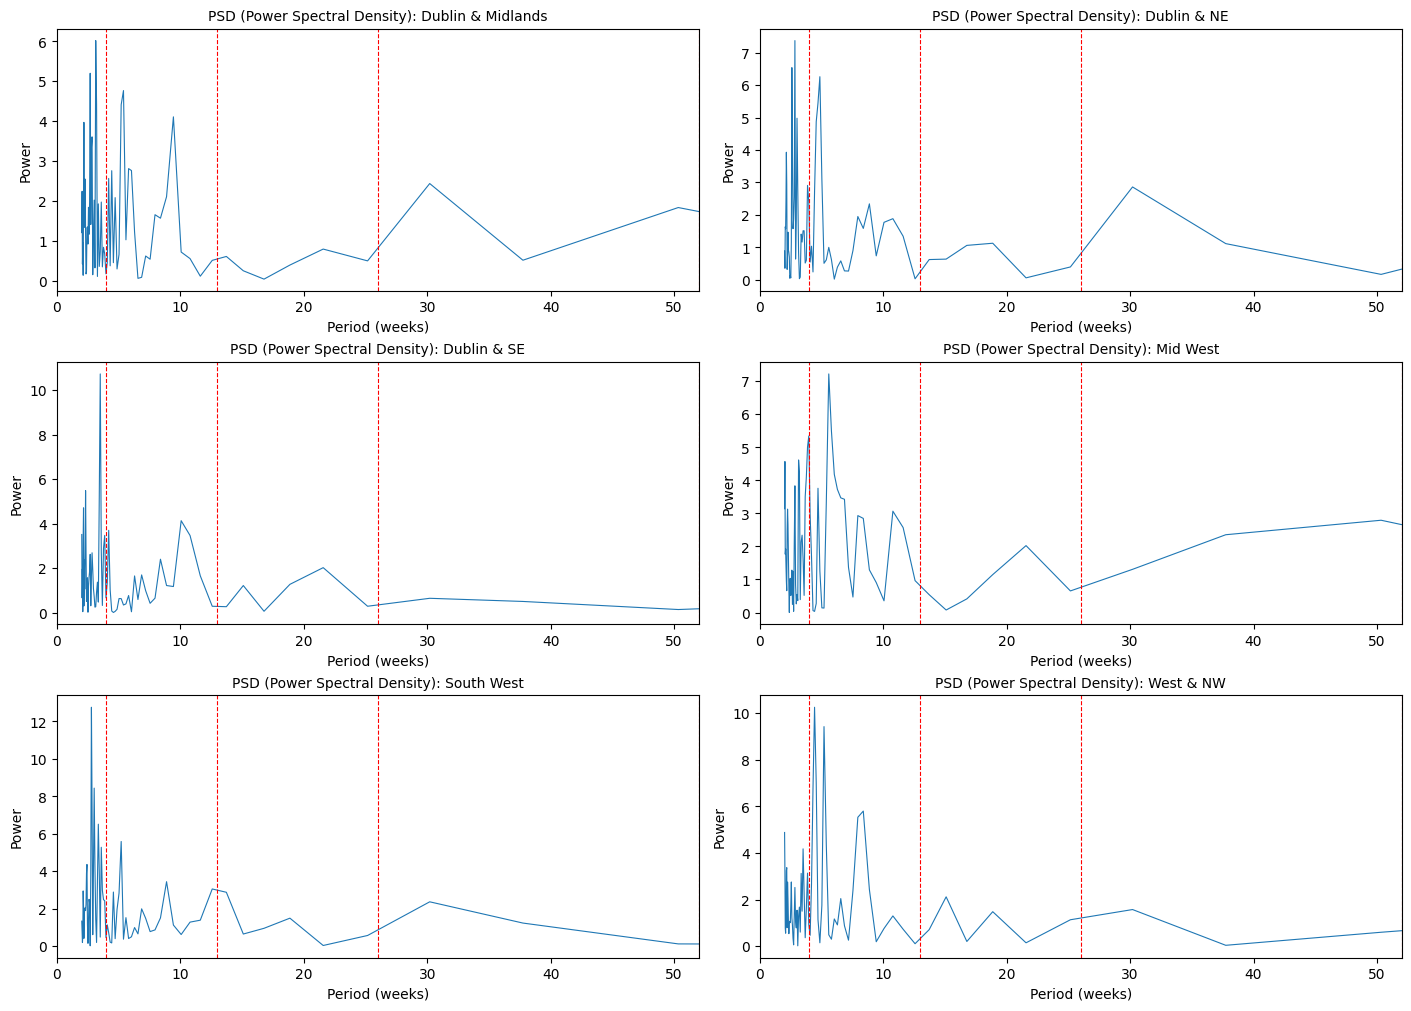

In [12]:
plot_residuals_periodogram(df_std_resid, PLOT_DIR + 'residuals_periodogram.png')

# Significance Testing

### Annual cycle amplitude
$$\hat{A} = \sqrt{\beta^2 + \gamma^2}$$

- Tests whether the seasonal cycle has a practically meaningful magnitude
- $P(A_i > \varepsilon)$ where $\varepsilon = 0.5$ trolleys per 10k
- No hypothesis test — direct posterior probability statement

In [14]:
ampl = compute_amplitude(raw_df, regions)

In [15]:
epsilon = 0.5

results = []
for region in regions:
    a = ampl[region]
    post_p = (a > epsilon).mean()
    results.append({
        'Region':        region,
        'Mean A':        round(a.mean(), 3),
        'Median A':      round(np.median(a), 3),
        '2.5%':          round(np.quantile(a, 0.025), 3),
        '97.5%':         round(np.quantile(a, 0.975), 3),
        f'P(A > {epsilon})': round(post_p, 3),
    })

df_ampl_overall = pd.DataFrame(results).sort_values(f'P(A > {epsilon})', ascending=False)
df_ampl_overall.to_csv(DATA_DIR + 'amplitude_overall.csv', index=False)
df_ampl_overall

,Region,Mean A,Median A,2.5%,97.5%,P(A > 0.5)
0,HSE Dublin and Midlands,1.044,1.041,0.547,1.554,0.984
4,HSE South West,1.071,1.067,0.443,1.711,0.963
1,HSE Dublin and North East,0.794,0.794,0.449,1.147,0.953
2,HSE Dublin and South East,0.764,0.763,0.379,1.153,0.912
3,HSE Mid West,0.645,0.614,0.120,1.357,0.637
5,HSE West and North West,0.574,0.549,0.107,1.195,0.565


### Annual cycle amplitude — pairwise

In [17]:
df_ampl_pw = pairwise_test(ampl, regions, epsilon=0.5)
df_ampl_pw.to_csv(DATA_DIR + 'amplitude_pairwise.csv', index=False)
df_ampl_pw

,Region A,Region B,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,HSE Dublin and Midlands,HSE Dublin and North East,0.249,-0.357,0.862,0.215,0.789,0.211
1,HSE Dublin and Midlands,HSE Dublin and South East,0.280,-0.348,0.917,0.253,0.808,0.192
2,HSE Dublin and Midlands,HSE Mid West,0.399,-0.458,1.156,0.440,0.833,0.167
3,HSE Dublin and Midlands,HSE South West,-0.027,-0.835,0.778,0.223,0.473,0.527
4,HSE Dublin and Midlands,HSE West and North West,0.469,-0.321,1.179,0.493,0.886,0.114
5,HSE Dublin and North East,HSE Dublin and South East,0.030,-0.489,0.553,0.062,0.546,0.454
6,HSE Dublin and North East,HSE Mid West,0.149,-0.639,0.793,0.224,0.674,0.326
7,HSE Dublin and North East,HSE South West,-0.276,-1.008,0.441,0.288,0.226,0.774
8,HSE Dublin and North East,HSE West and North West,0.220,-0.486,0.816,0.233,0.751,0.249
9,HSE Dublin and South East,HSE Mid West,0.119,-0.683,0.789,0.218,0.644,0.356


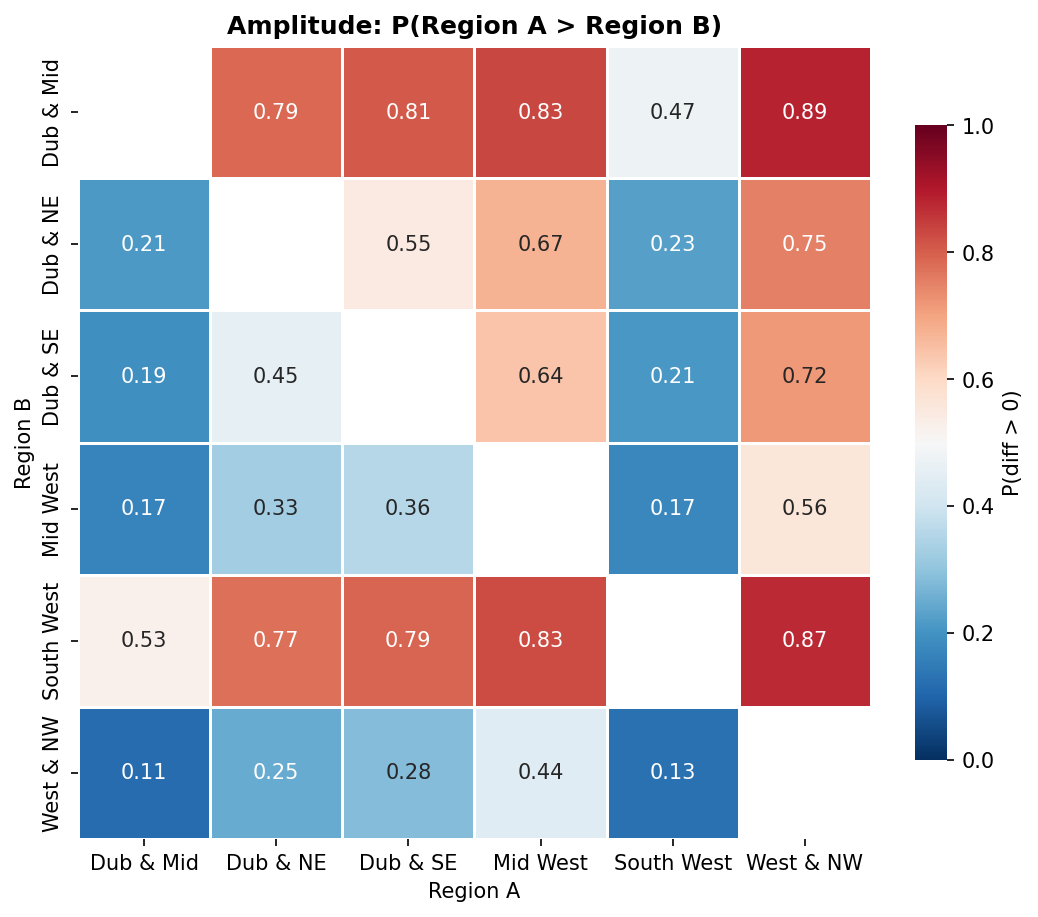

In [18]:
pairwise_heatmap(df_ampl_pw, 'P(diff > 0)',
                 'Amplitude: P(Region A > Region B)',
                 PLOT_DIR + 'amplitude_pairwise.png')

### Phase cycles — overall test

The seasonal component is $\beta_i \cos(\frac{2\pi t}{52}) + \gamma_i \sin(\frac{2\pi t}{52})$, which peaks when:

$$t_{\text{peak}} = \frac{52}{2\pi}\;\text{arctan2}(\gamma_i,\, \beta_i)$$

- We use `arctan2` instead of `arctan`
- `arctan(γ/β)` only returns values in $(-\pi/2,\, \pi/2)$ — it cannot distinguish which quadrant the angle falls in.
- This matters because $\beta$ and $\gamma$ can both be negative (peak in summer), and `arctan(γ/β)` would collapse that to the same angle as both positive (peak in winter).

### Peak week forest plot — winter band

#### Bayes Factors vs posterior probability

$$BF = \frac{\text{posterior odds}}{\text{prior odds}}$$

Phase winter test:

$$\text{prior odds} = \frac{P(\text{winter})}{P(\neg\text{winter})} = \frac{9/52}{43/52} = \frac{9}{43}$$

$$\text{posterior odds} = \frac{P(\text{winter} \mid \text{data})}{P(\neg\text{winter} \mid \text{data})}$$

### Phase cycles — flu season test
- Based on visual inspection of a distribution from Green et al. (2015), flu season in northern ireland was round 48-14 months
- This is somewhat arbitrary and can be formally inspected

In [19]:
flu_season_weeks    = (48, 14)
prior_winter        = (4+14) / 52
flu_key = f'{flu_season_weeks[0]} < phase < {flu_season_weeks[1]}'  
ci_lower_q, ci_upper_q = 0.025, 0.975


results = []
for i, region in enumerate(regions):
    b = raw_df[f'beta[{i+1}]'].values
    g = raw_df[f'gamma[{i+1}]'].values
    phase_rad = np.arctan2(g, b)
    peak_weeks = (52 / (2 * np.pi) * phase_rad) % 52
    mean_peak_wk = ((52 / (2 * np.pi)) * phase_rad.mean()) % 52
    median_peak_wk = ((52 / (2 * np.pi)) * np.median(phase_rad)) % 52

    prob_winter = ((peak_weeks >= flu_season_weeks[0]) | (peak_weeks <= flu_season_weeks[1])).mean()

    post_odds_w = prob_winter / max(1 - prob_winter, 1e-10)
    prior_odds_w = prior_winter / (1 - prior_winter)
    bf_winter = post_odds_w / prior_odds_w


    b = raw_df[f'beta[{i+1}]'].values
    g = raw_df[f'gamma[{i+1}]'].values
    phase = np.arctan2(g, b)
    lo_rad, hi_rad = np.quantile(phase, [ci_lower_q, ci_upper_q])
    mean_wk = ((52 / (2 * np.pi)) * phase.mean()) % 52
    lo_wk = ((52 / (2 * np.pi)) * lo_rad) % 52
    hi_wk = ((52 / (2 * np.pi)) * hi_rad) % 52
    ci_width = (hi_wk - lo_wk) % 52
    
    results.append({
        'Region': region,
        'Mean peak week': round(mean_peak_wk, 2),
        'Median peak week': round(median_peak_wk, 2),
        f'P({flu_key})': round(prob_winter, 3),
        f'P({flu_key})': round(prob_winter, 3),
        '2.5%': round(lo_wk, 1),
        '97.5%': round(hi_wk, 1),
        'CI Width': round(ci_width, 1),
    })
df_season_phase_test = pd.DataFrame(results).sort_values(f'P({flu_key})', ascending=False)
df_season_phase_test.to_csv(DATA_DIR + 'seasonal_phase_test.csv', index=False)
df_season_phase_test

,Region,Mean peak week,Median peak week,P(48 < phase < 14),2.5%,97.5%,CI Width
1,HSE Dublin and North East,3.32,3.31,0.999,51.4,7.2,7.8
0,HSE Dublin and Midlands,6.97,6.97,0.998,2.5,11.4,8.9
2,HSE Dublin and South East,2.38,2.38,0.994,49.8,7.0,9.3
4,HSE South West,2.42,2.41,0.982,48.7,8.2,11.6
5,HSE West and North West,6.01,6.99,0.714,32.0,22.2,42.2
3,HSE Mid West,9.66,14.99,0.279,27.0,25.1,50.1


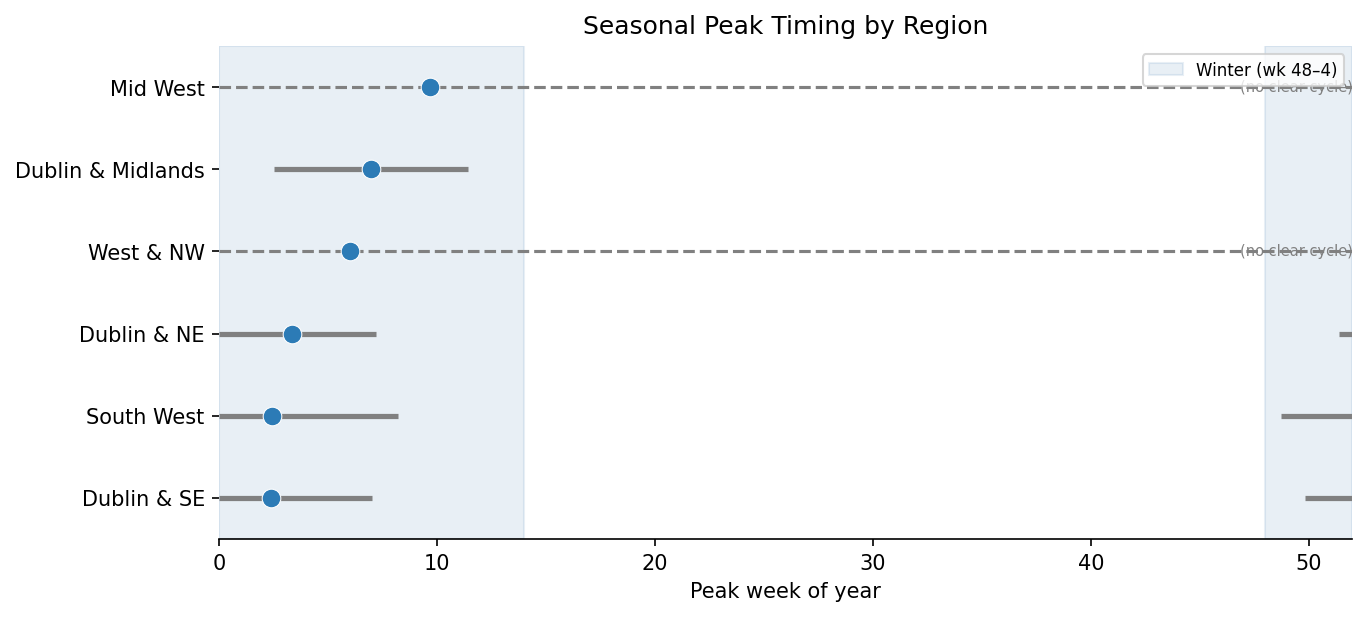

In [20]:
flu_season_weeks = (48, 14)

df_plot = df_season_phase_test.sort_values('Mean peak week')
lo_wk = df_plot['2.5%'].values
hi_wk = df_plot['97.5%'].values

def ci_width(lo, hi):
    return (hi - lo) % 52

fig, ax = plt.subplots(figsize=(9, 4), dpi=150, layout='constrained')
y_pos = list(range(len(df_plot)))

ax.axvspan(flu_season_weeks[0], 52, alpha=0.12, color='steelblue', label='Winter (wk 48\u20134)')
ax.axvspan(0, flu_season_weeks[1], alpha=0.12, color='steelblue')

for y, lo, hi, region in zip(y_pos, lo_wk, hi_wk, df_plot['Region'].values):
    width = ci_width(lo, hi)
    if width > 40:
        style = dict(color='grey', linewidth=1.5, linestyle='--', zorder=1)
        ax.hlines(y, 0, 52, **style)
        ax.annotate('(no clear cycle)', xy=(52, y), fontsize=7,
                    color='grey', va='center', ha='right')
    elif lo <= hi:
        ax.hlines(y, lo, hi, color='grey', linewidth=2.5, zorder=2)
    else:
        ax.hlines(y, lo, 52, color='grey', linewidth=2.5, zorder=2)
        ax.hlines(y, 0, hi, color='grey', linewidth=2.5, zorder=2)

ax.scatter(df_plot['Mean peak week'].values, y_pos, s=80, zorder=3,
           color='#2c7bb6', edgecolors='white', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels([SHORT_NAMES.get(r, r) for r in df_plot['Region'].values])
ax.set_xlabel('Peak week of year')
ax.set_xlim(0, 52)
ax.set_ylim(-0.5, len(y_pos) - 0.5)
ax.set_title('Seasonal Peak Timing by Region')
ax.legend(loc='upper right', fontsize=8)
sns.despine(left=True)
fig.savefig(PLOT_DIR + 'seasonal_phase_test.png', bbox_inches='tight', dpi=150)
plt.show()

## Alpha baseline
Global parameter summaries, regional map, and credible intervals for the region intercepts.

In [21]:
global_params = {
    'mu_alpha':  raw_df['mu_alpha'].values,
    'phi':       raw_df['phi'].values,
}

rows = []
for name, vals in global_params.items():
    rows.append({
        'Parameter': name,
        'Mean':      vals.mean(),
        'SD':        vals.std(),
        '2.5%':      np.quantile(vals, 0.025),
        '97.5%':     np.quantile(vals, 0.975),
    })

df_global = pd.DataFrame(rows).round(4)
df_global.to_csv(DATA_DIR + 'global_parameters.csv', index=False)
df_global

,Parameter,Mean,SD,2.5%,97.5%
0,mu_alpha,4.6959,1.1597,2.3769,7.0208
1,phi,0.6604,0.0282,0.6055,0.7158


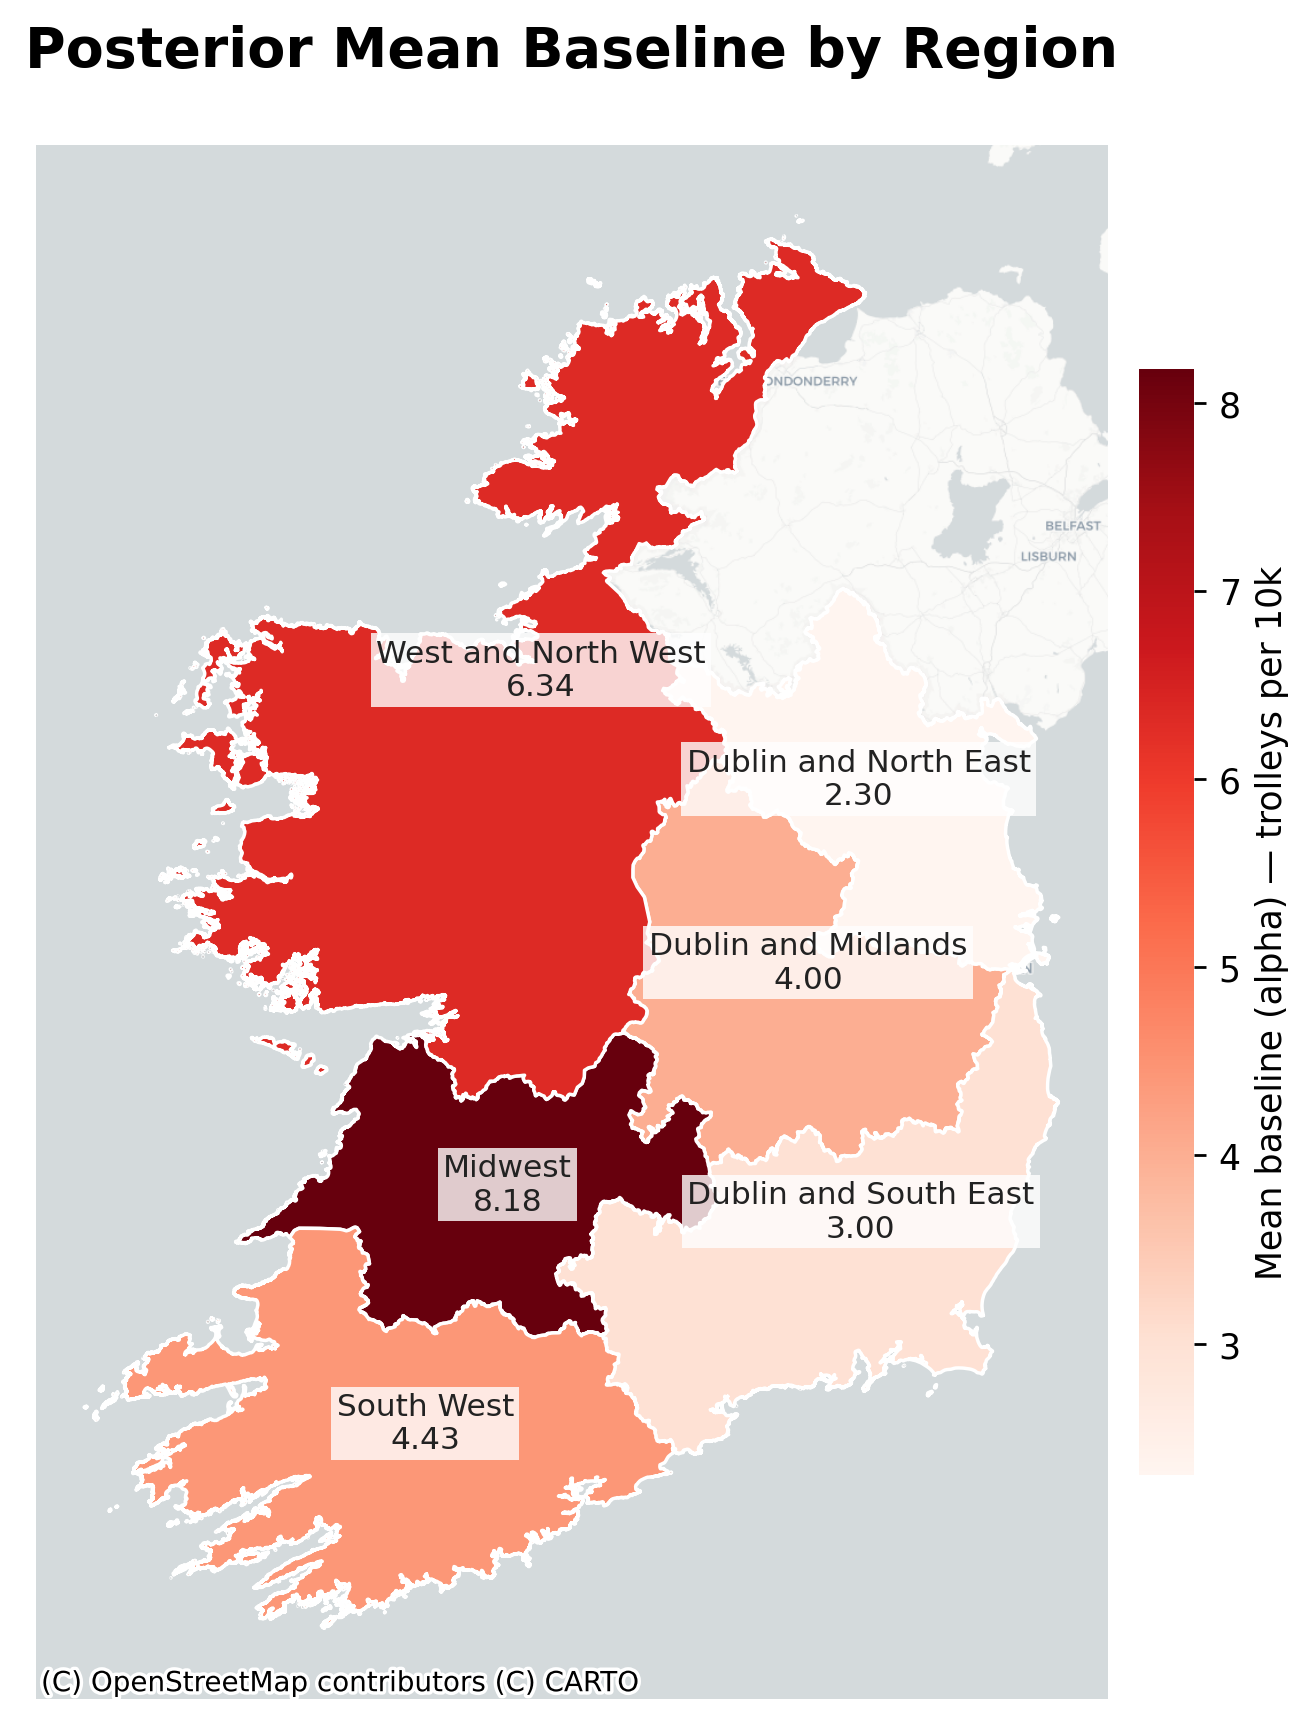

In [22]:
import geopandas as gpd
import matplotlib as mpl
import contextily as ctx

alpha_means = pd.DataFrame({
    'Region': regions,
    'mean_alpha': [raw_df[f'alpha[{i+1}]'].mean() for i in range(n_region)]
})
alpha_means['mean_alpha'] = alpha_means['mean_alpha'].round(2)

name_map = {
    'HSE Dublin and Midlands': 'HSE Dublin and Midlands HR',
    'HSE Dublin and North East': 'HSE Dublin and North East HR',
    'HSE Dublin and South East': 'HSE Dublin and South East HR',
    'HSE Mid West': 'HSE Midwest HR',
    'HSE South West': 'HSE South West HR',
    'HSE West and North West': 'HSE West and North West HR',
}
alpha_means['HR_operational_name'] = alpha_means['Region'].map(name_map)

gdf = gpd.read_file('../../data/mapping/hse_regions.geojson')
if gdf.crs is None:
    gdf = gdf.set_crs('EPSG:4326')
gdf = gdf.merge(alpha_means[['HR_operational_name', 'mean_alpha']], on='HR_operational_name', how='left')
gdf_3857 = gdf.to_crs(epsg=3857)
gdf_3857['label_point'] = gdf_3857.geometry.representative_point()

fig, ax = plt.subplots(figsize=(7, 7), dpi=250)
cmap = mpl.cm.Reds
vmin, vmax = float(gdf_3857['mean_alpha'].min()), float(gdf_3857['mean_alpha'].max())
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

gdf_3857.plot(column='mean_alpha', ax=ax, cmap=cmap, norm=norm, edgecolor='white', linewidth=1.0)

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron)
except Exception as e:
    print(f'Basemap skipped: {e}')

for _, row in gdf_3857.iterrows():
    if pd.isna(row['mean_alpha']):
        continue
    x, y = row['label_point'].x, row['label_point'].y
    short = row['HR_operational_name'].replace(' HR', '').replace('HSE ', '')
    label = f"{short}\n{row['mean_alpha']:.2f}"
    ax.text(x, y, label, ha='center', va='center', fontsize=9, color='#222',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1.5), zorder=5)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
cbar = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Mean baseline (alpha) — trolleys per 10k', fontsize=10)
cbar.outline.set_visible(False)

ax.set_title('Posterior Mean Baseline by Region', fontsize=16, pad=12, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
fig.savefig(PLOT_DIR + 'alpha_overall.png', bbox_inches='tight', dpi=150)
plt.show()

In [23]:
results = []
for i, region in enumerate(regions):
    vals = raw_df[f'alpha[{i+1}]'].values
    ci_lower, ci_upper = np.quantile(vals, [0.025, 0.975])
    results.append({
        'Region':     region,
        'Mean':       vals.mean(),
        'Median':     np.median(vals),
        'SD':         vals.std(),
        '2.5%':       ci_lower,
        '97.5%':      ci_upper,
    })

df_alpha_overall = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
df_alpha_overall.to_csv(DATA_DIR + 'alpha_overall.csv', index=False)
df_alpha_overall

,Region,Mean,Median,SD,2.5%,97.5%
3,HSE Mid West,8.182,8.183,0.306,7.572,8.776
5,HSE West and North West,6.336,6.337,0.266,5.813,6.861
4,HSE South West,4.426,4.426,0.243,3.948,4.905
0,HSE Dublin and Midlands,3.998,3.999,0.192,3.620,4.377
2,HSE Dublin and South East,3.002,3.001,0.147,2.712,3.291
1,HSE Dublin and North East,2.298,2.297,0.133,2.038,2.560


### Alpha baseline — overall test
$$H_0: \alpha_i = 0 \quad H_a: \alpha_i \neq 0$$

Tests whether each region's baseline trolley rate is significantly different from zero.

### Alpha baseline — pairwise test
Tests on $\alpha_i$ directly (the region intercepts).

In [24]:
alpha_samples = {regions[i]: raw_df[f'alpha[{i+1}]'].values for i in range(n_region)}
df_alpha_pw = pairwise_test(alpha_samples, regions)
df_alpha_pw.to_csv(DATA_DIR + 'alpha_pairwise.csv', index=False)
df_alpha_pw

,Region A,Region B,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,HSE Dublin and Midlands,HSE Dublin and North East,1.701,1.242,2.154,1.000,1.000,0.000
1,HSE Dublin and Midlands,HSE Dublin and South East,0.997,0.522,1.470,0.980,1.000,0.000
2,HSE Dublin and Midlands,HSE Mid West,-4.183,-4.887,-3.465,1.000,0.000,1.000
3,HSE Dublin and Midlands,HSE South West,-0.427,-1.039,0.185,0.408,0.084,0.916
4,HSE Dublin and Midlands,HSE West and North West,-2.338,-2.981,-1.691,1.000,0.000,1.000
5,HSE Dublin and North East,HSE Dublin and South East,-0.704,-1.089,-0.312,0.852,0.000,1.000
6,HSE Dublin and North East,HSE Mid West,-5.884,-6.534,-5.220,1.000,0.000,1.000
7,HSE Dublin and North East,HSE South West,-2.128,-2.675,-1.578,1.000,0.000,1.000
8,HSE Dublin and North East,HSE West and North West,-4.039,-4.621,-3.452,1.000,0.000,1.000
9,HSE Dublin and South East,HSE Mid West,-5.180,-5.839,-4.503,1.000,0.000,1.000


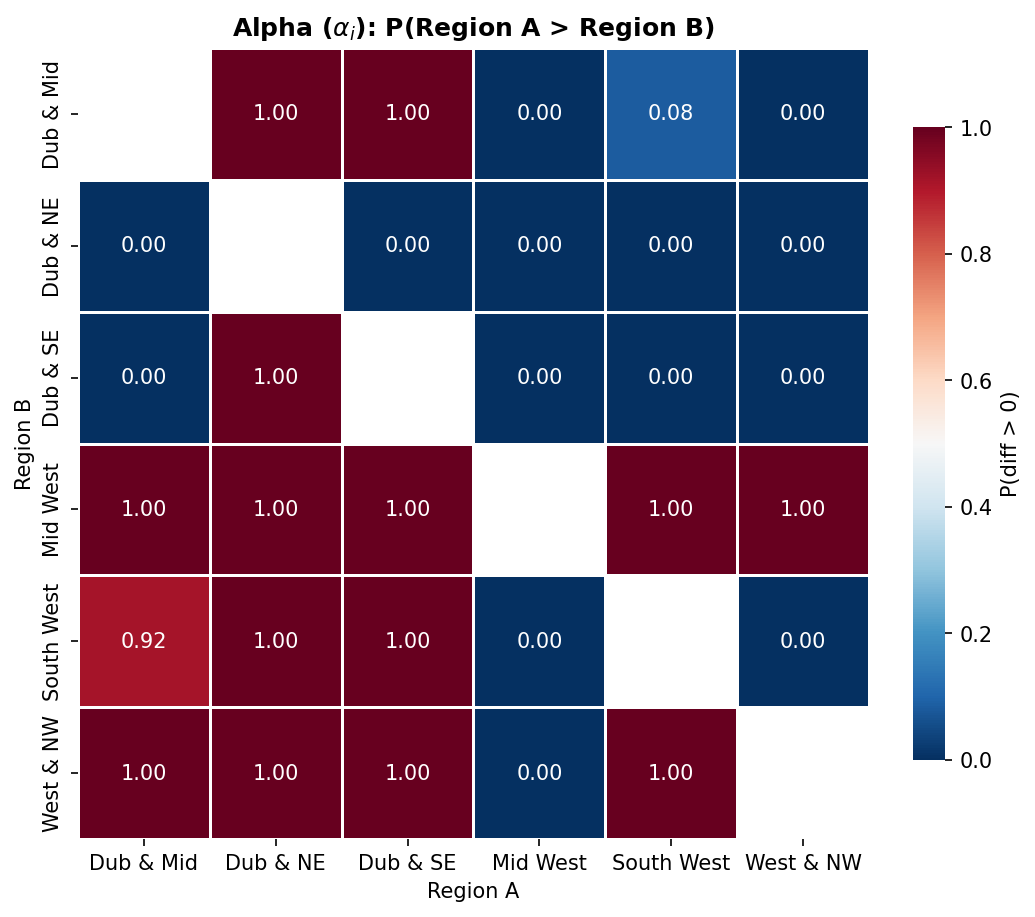

In [25]:
pairwise_heatmap(df_alpha_pw, 'P(diff > 0)',
                 r'Alpha ($\alpha_i$): P(Region A > Region B)',
                 PLOT_DIR + 'alpha_pairwise.png')

### New Year — delta (per-region)
V4 fits `delta_pre[i]`, `delta_mid[i]`, `delta_post[i]` per region (same as V3).

In [26]:
delta_params = ['delta_pre', 'delta_mid', 'delta_post']
delta_samples = {}
for param in delta_params:
    delta_samples[param] = {}
    for i in range(n_region):
        delta_samples[param][regions[i]] = raw_df[f'{param}[{i+1}]'].values

In [27]:
for param in delta_params:
    results = []
    for region in regions:
        vals = delta_samples[param][region]
        ci_lower, ci_upper = np.quantile(vals, [0.025, 0.975])
        results.append({
            'Region': region, 'Mean': vals.mean(),
            '2.5%': ci_lower,
            '97.5%': ci_upper,
            'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
        })
    df_sig = pd.DataFrame(results).sort_values('Mean', ascending=False).round(3)
    print(f'\n=== Overall: {param} ===')
    display(df_sig)
    df_sig.to_csv(DATA_DIR + f'delta_overall_{param}.csv', index=False)

delta_combined_rows = []
for param in delta_params:
    df_part = pd.read_csv(DATA_DIR + f'delta_overall_{param}.csv')
    df_part.insert(0, 'Parameter', param.replace('delta_', '').title())
    delta_combined_rows.append(df_part)
df_delta_combined = pd.concat(delta_combined_rows, ignore_index=True)
df_delta_combined.to_csv(DATA_DIR + 'delta_overall_combined.csv', index=False)


=== Overall: delta_pre ===


,Region,Mean,2.5%,97.5%,Sig
1,HSE Dublin and North East,-1.170,-1.881,-0.456,Yes
3,HSE Mid West,-1.278,-2.915,0.357,No
2,HSE Dublin and South East,-1.428,-2.216,-0.644,Yes
4,HSE South West,-1.457,-2.779,-0.119,Yes
0,HSE Dublin and Midlands,-1.803,-2.858,-0.759,Yes
5,HSE West and North West,-2.086,-3.527,-0.638,Yes



=== Overall: delta_mid ===


,Region,Mean,2.5%,97.5%,Sig
1,HSE Dublin and North East,-2.459,-3.137,-1.777,Yes
2,HSE Dublin and South East,-2.867,-3.613,-2.114,Yes
0,HSE Dublin and Midlands,-3.900,-4.895,-2.904,Yes
4,HSE South West,-4.086,-5.340,-2.830,Yes
5,HSE West and North West,-4.914,-6.281,-3.545,Yes
3,HSE Mid West,-5.425,-6.978,-3.863,Yes



=== Overall: delta_post ===


,Region,Mean,2.5%,97.5%,Sig
5,HSE West and North West,1.600,0.376,2.836,Yes
4,HSE South West,0.506,-0.625,1.637,No
3,HSE Mid West,0.120,-1.287,1.532,No
2,HSE Dublin and South East,0.061,-0.626,0.737,No
0,HSE Dublin and Midlands,-0.050,-0.952,0.851,No
1,HSE Dublin and North East,-0.212,-0.825,0.401,No


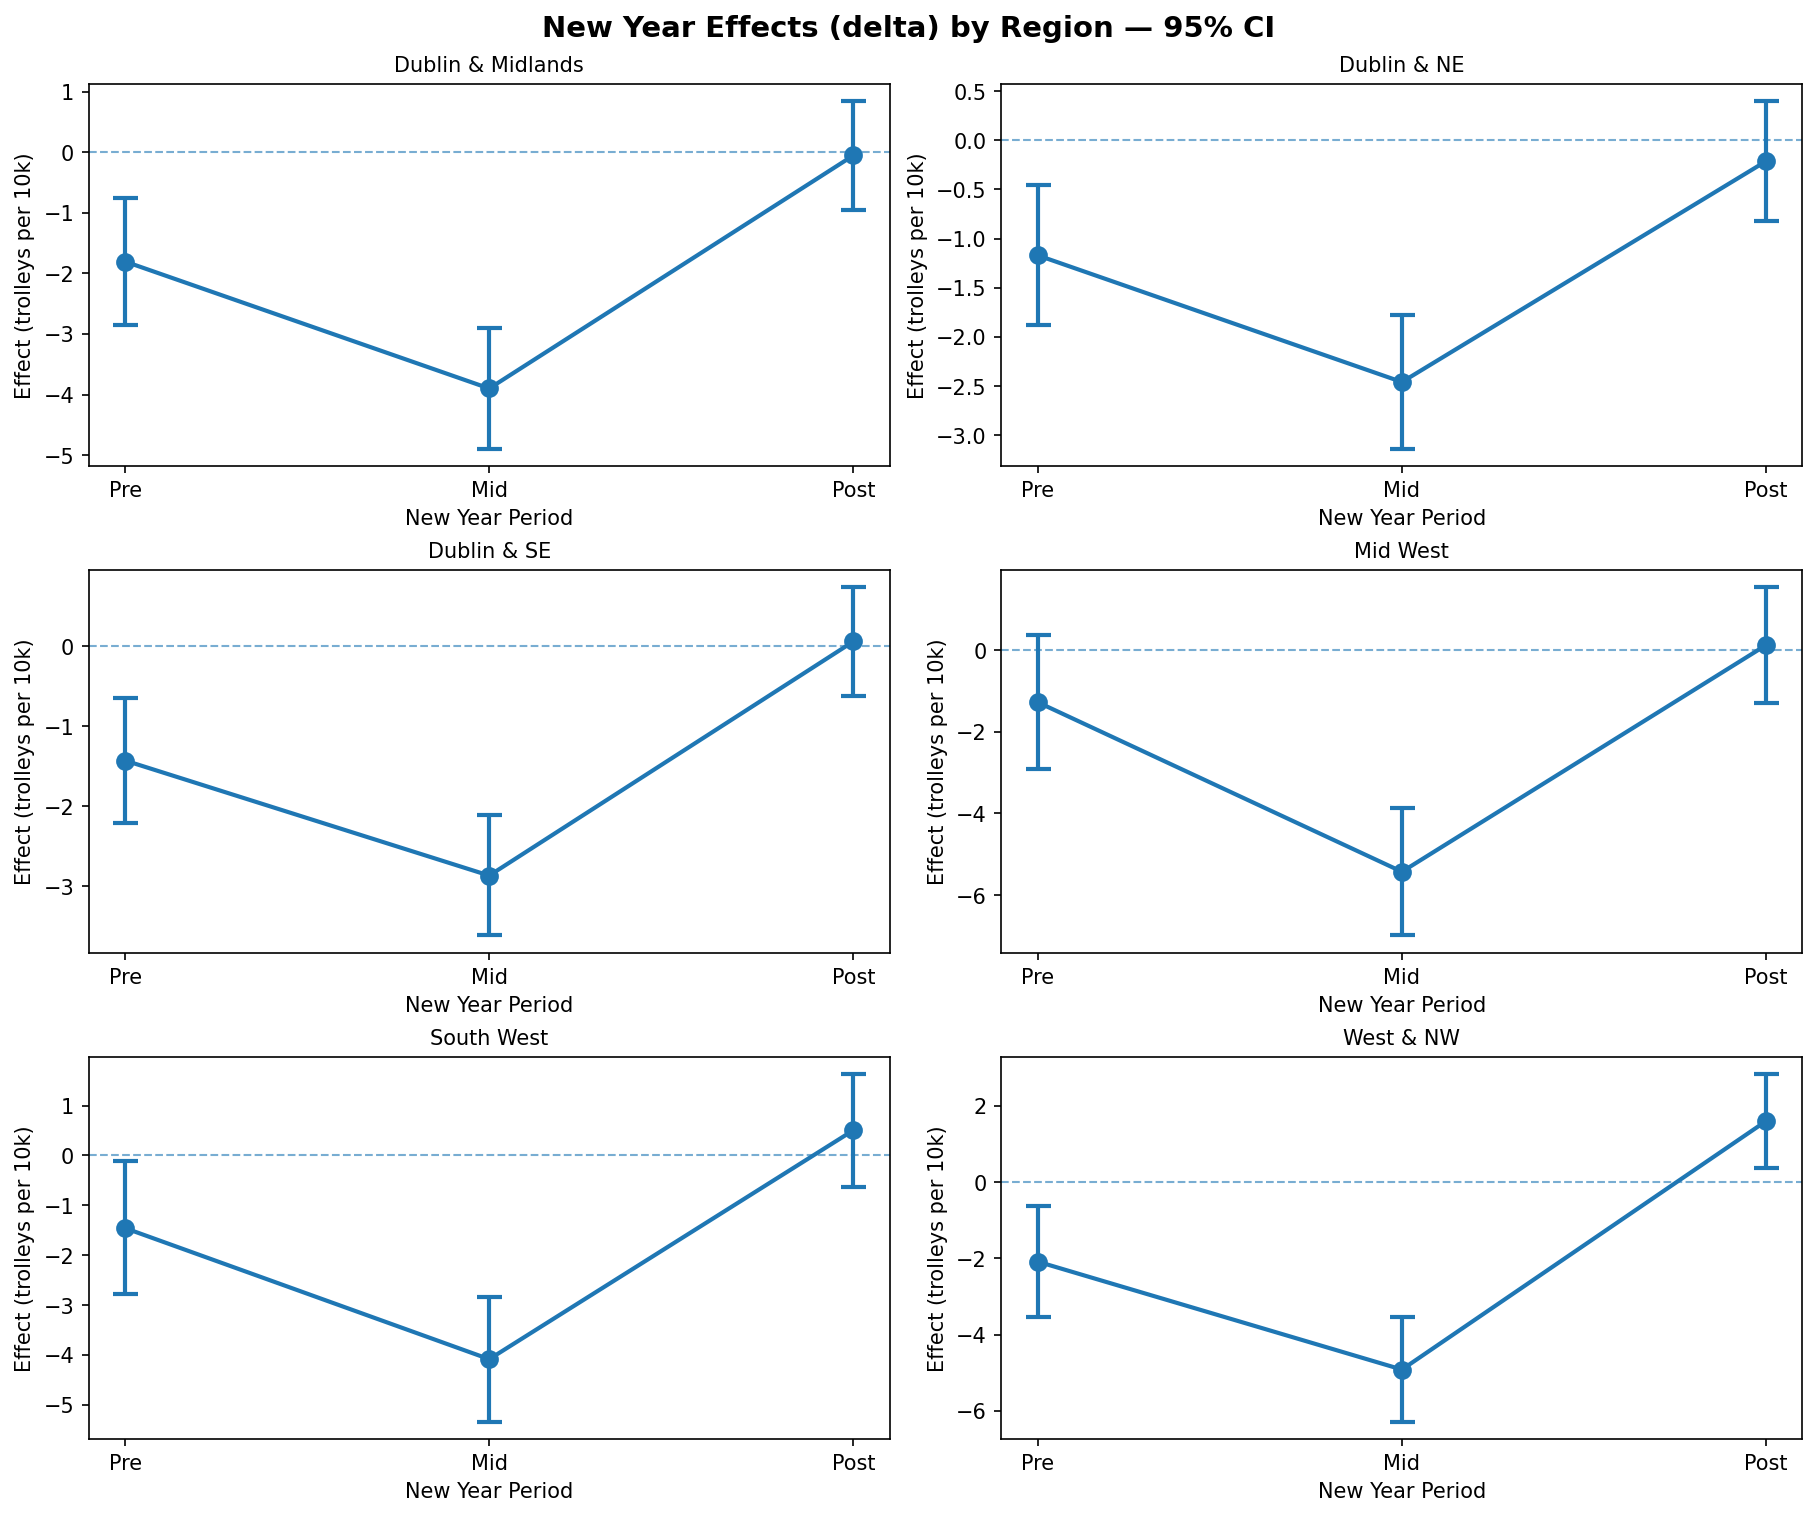

In [28]:
labels_nice = {'delta_pre': 'Pre', 'delta_mid': 'Mid', 'delta_post': 'Post'}
x_labels = [labels_nice[p] for p in delta_params]

fig, axes = plt.subplots(3, 2, figsize=(12, 10), dpi=150, layout='constrained')
for idx, (region, ax) in enumerate(zip(regions, axes.flatten())):
    means  = np.array([delta_samples[p][region].mean() for p in delta_params])
    ci_lo  = np.array([np.quantile(delta_samples[p][region], 0.025) for p in delta_params])
    ci_hi  = np.array([np.quantile(delta_samples[p][region], 0.975) for p in delta_params])
    ax.errorbar(x_labels, means, yerr=[means - ci_lo, ci_hi - means],
                fmt='o-', linewidth=2, markersize=8, capsize=6, capthick=2, elinewidth=2, zorder=3)
    ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
    ax.set_title(SHORT_NAMES.get(region, region), fontsize=10)
    ax.set_xlabel('New Year Period')
    ax.set_ylabel('Effect (trolleys per 10k)')
fig.suptitle('New Year Effects (delta) by Region — 95% CI', fontsize=14, fontweight='bold')
fig.savefig(PLOT_DIR + 'delta_overall_combined.png', bbox_inches='tight', dpi=150)
plt.show()

### New Year — delta pairwise (per-region)

In [29]:
for param in delta_params:
    results = []
    for r1, r2 in combinations(range(n_region), 2):
        diff = delta_samples[param][regions[r1]] - delta_samples[param][regions[r2]]
        ci_lower, ci_upper = np.quantile(diff, [0.025, 0.975])
        p_dir = (diff > 0).mean()
        p_abs = (np.abs(diff) > 0.5).mean()
        results.append({
            'Region1': regions[r1], 'Region2': regions[r2],
            'MeanDiff': diff.mean(),
            '2.5%': ci_lower,
            '97.5%': ci_upper,
            'P(|diff| > 0.5)': round(p_abs, 3),
            'P(diff > 0)': round(p_dir, 3),
            'P(diff < 0)': round(1 - p_dir, 3),
        })
    df_pw = pd.DataFrame(results).round(3)
    print(f'\n=== Pairwise: {param} ===')
    display(df_pw)
    df_pw.to_csv(DATA_DIR + f'delta_pairwise_{param}.csv', index=False)

delta_pw_combined_rows = []
for param in delta_params:
    df_part = pd.read_csv(DATA_DIR + f'delta_pairwise_{param}.csv')
    df_part.insert(0, 'Parameter', param.replace('delta_', '').title())
    delta_pw_combined_rows.append(df_part)
df_delta_pw_combined = pd.concat(delta_pw_combined_rows, ignore_index=True)
df_delta_pw_combined.to_csv(DATA_DIR + 'delta_pairwise_combined.csv', index=False)


=== Pairwise: delta_pre ===


,Region1,Region2,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,HSE Dublin and Midlands,HSE Dublin and North East,-0.633,-1.906,0.639,0.622,0.164,0.836
1,HSE Dublin and Midlands,HSE Dublin and South East,-0.375,-1.687,0.939,0.520,0.287,0.713
2,HSE Dublin and Midlands,HSE Mid West,-0.525,-2.489,1.416,0.658,0.299,0.701
3,HSE Dublin and Midlands,HSE South West,-0.346,-2.034,1.341,0.592,0.342,0.658
4,HSE Dublin and Midlands,HSE West and North West,0.283,-1.500,2.063,0.600,0.622,0.378
5,HSE Dublin and North East,HSE Dublin and South East,0.258,-0.806,1.316,0.408,0.683,0.317
6,HSE Dublin and North East,HSE Mid West,0.108,-1.680,1.896,0.583,0.548,0.452
7,HSE Dublin and North East,HSE South West,0.287,-1.218,1.783,0.541,0.649,0.351
8,HSE Dublin and North East,HSE West and North West,0.916,-0.702,2.527,0.735,0.867,0.133
9,HSE Dublin and South East,HSE Mid West,-0.151,-1.953,1.669,0.591,0.435,0.565



=== Pairwise: delta_mid ===


,Region1,Region2,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,HSE Dublin and Midlands,HSE Dublin and North East,-1.442,-2.652,-0.238,0.939,0.009,0.991
1,HSE Dublin and Midlands,HSE Dublin and South East,-1.033,-2.280,0.209,0.809,0.051,0.949
2,HSE Dublin and Midlands,HSE Mid West,1.525,-0.331,3.362,0.878,0.947,0.053
3,HSE Dublin and Midlands,HSE South West,0.186,-1.418,1.789,0.549,0.592,0.408
4,HSE Dublin and Midlands,HSE West and North West,1.014,-0.668,2.695,0.764,0.880,0.120
5,HSE Dublin and North East,HSE Dublin and South East,0.408,-0.594,1.410,0.470,0.787,0.213
6,HSE Dublin and North East,HSE Mid West,2.967,1.268,4.656,0.998,1.000,0.000
7,HSE Dublin and North East,HSE South West,1.627,0.207,3.059,0.941,0.988,0.012
8,HSE Dublin and North East,HSE West and North West,2.456,0.917,3.979,0.994,0.999,0.001
9,HSE Dublin and South East,HSE Mid West,2.558,0.827,4.274,0.990,0.998,0.002



=== Pairwise: delta_post ===


,Region1,Region2,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,HSE Dublin and Midlands,HSE Dublin and North East,0.162,-0.926,1.248,0.388,0.617,0.383
1,HSE Dublin and Midlands,HSE Dublin and South East,-0.111,-1.244,1.013,0.392,0.423,0.577
2,HSE Dublin and Midlands,HSE Mid West,-0.170,-1.847,1.502,0.564,0.420,0.580
3,HSE Dublin and Midlands,HSE South West,-0.557,-1.998,0.885,0.606,0.225,0.775
4,HSE Dublin and Midlands,HSE West and North West,-1.650,-3.177,-0.128,0.934,0.017,0.983
5,HSE Dublin and North East,HSE Dublin and South East,-0.273,-1.188,0.641,0.363,0.279,0.721
6,HSE Dublin and North East,HSE Mid West,-0.332,-1.866,1.201,0.558,0.335,0.665
7,HSE Dublin and North East,HSE South West,-0.719,-2.006,0.568,0.664,0.137,0.863
8,HSE Dublin and North East,HSE West and North West,-1.812,-3.191,-0.438,0.970,0.005,0.995
9,HSE Dublin and South East,HSE Mid West,-0.059,-1.631,1.511,0.530,0.470,0.530


### Full Reset — sigma (global, Mid West only)

In [30]:
sigma_samples_global = raw_df[['sigma_pre', 'sigma_mid', 'sigma_post']]
sigma_params = ['sigma_pre', 'sigma_mid', 'sigma_post']

results = []
for param in sigma_params:
    vals = sigma_samples_global[param]
    ci_lower, ci_upper = np.quantile(vals, [0.025, 0.975])
    results.append({
        'Parameter': param, 'Mean': vals.mean(),
        '2.5%': ci_lower,
        '97.5%': ci_upper,
        'Sig': 'Yes' if ci_lower > 0 or ci_upper < 0 else 'No'
    })

df_sigma_ind = pd.DataFrame(results).round(3)
df_sigma_ind.to_csv(DATA_DIR + 'full_reset_overall.csv', index=False)
df_sigma_ind

,Parameter,Mean,2.5%,97.5%,Sig
0,sigma_pre,-4.180,-6.578,-1.760,Yes
1,sigma_mid,-7.191,-9.916,-4.472,Yes
2,sigma_post,-3.655,-6.063,-1.248,Yes


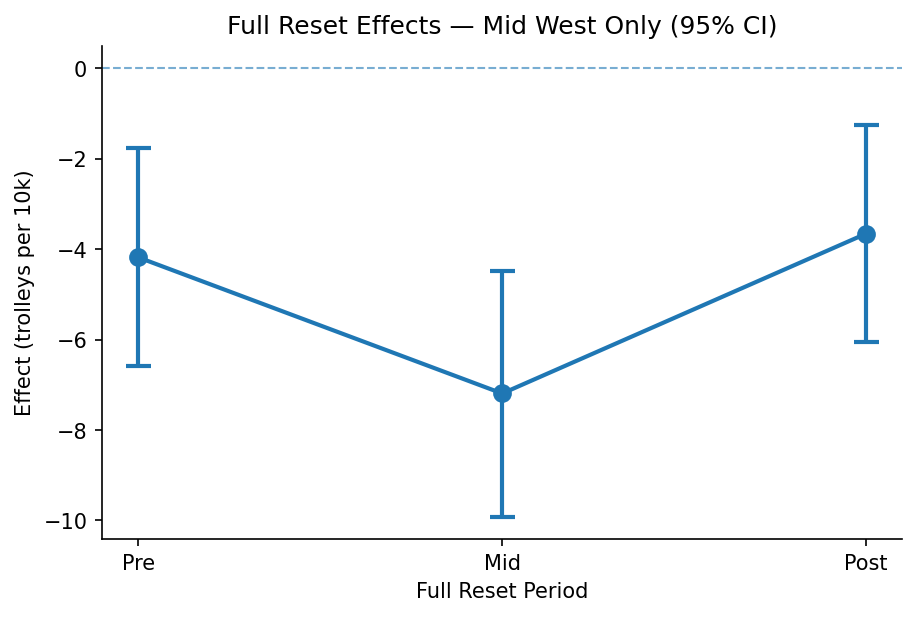

In [31]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=150, layout='constrained')
ax.errorbar(['Pre', 'Mid', 'Post'], df_sigma_ind['Mean'].values,
            yerr=[df_sigma_ind['Mean'].values - df_sigma_ind['2.5%'].values,
                  df_sigma_ind['97.5%'].values - df_sigma_ind['Mean'].values],
            fmt='o-', linewidth=2, markersize=8,
            capsize=6, capthick=2, elinewidth=2, zorder=3)
ax.axhline(0, linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('Full Reset Period')
ax.set_ylabel('Effect (trolleys per 10k)')
ax.set_title('Full Reset Effects — Mid West Only (95% CI)')
sns.despine(ax=ax)
fig.savefig(PLOT_DIR + 'full_reset_overall.png', bbox_inches='tight', dpi=150)
plt.show()

In [32]:
results = []
for a, b in combinations(sigma_params, 2):
    diff = sigma_samples_global[a] - sigma_samples_global[b]
    ci_lower, ci_upper = np.quantile(diff, [0.025, 0.975])
    p_dir = (diff > 0).mean()
    p_abs = (np.abs(diff) > 0.5).mean()
    results.append({
        'Comparison': f'{a} - {b}', 'MeanDiff': diff.mean(),
        '2.5%': ci_lower,
        '97.5%': ci_upper,
        'P(|diff| > 0.5)': round(p_abs, 3),
        'P(diff > 0)': round(p_dir, 3),
        'P(diff < 0)': round(1 - p_dir, 3),
    })
df_sigma_pw = pd.DataFrame(results).round(3)
df_sigma_pw

,Comparison,MeanDiff,2.5%,97.5%,P(|diff| > 0.5),P(diff > 0),P(diff < 0)
0,sigma_pre - sigma_mid,3.011,0.469,5.526,0.977,0.990,0.010
1,sigma_pre - sigma_post,-0.525,-3.419,2.373,0.749,0.360,0.640
2,sigma_mid - sigma_post,-3.536,-6.068,-1.005,0.991,0.003,0.997


# Ranking
Ranked on $\alpha_i$ (region intercept) per MCMC draw.

Pandas ranking averages ties: 1, 2, 3, 3, 5 → 1, 2, 2.5, 2.5, 4, 5.

In [33]:
ranked_alpha = build_ranked_alpha(raw_df, regions)

### Tables

In [34]:
mean_ranks = ranked_alpha.mean(axis=0)
assigned_rank = mean_ranks.rank().astype(int)

rows = []
for region in ranked_alpha.columns:
    ranks = ranked_alpha[region]
    k = assigned_rank[region]
    p_k = (ranks == k).mean()
    rows.append({
        'Region': region,
        'Mean Rank': round(ranks.mean(), 2),
        'Assigned Rank': k,
        'P(assigned rank)': round(p_k, 3),
        'SD': round(ranks.std(), 2),
        '2.5%': ranks.quantile(.025),
        '97.5%': ranks.quantile(.975),
    })

final_ranked_df = pd.DataFrame(rows).sort_values('Mean Rank')
final_ranked_df.to_csv(DATA_DIR + 'ranks.csv', index=False)
final_ranked_df

,Region,Mean Rank,Assigned Rank,P(assigned rank),SD,2.5%,97.5%
1,HSE Dublin and North East,1.00,1,1.000,0.02,1.0,1.0
2,HSE Dublin and South East,2.00,2,1.000,0.02,2.0,2.0
0,HSE Dublin and Midlands,3.08,3,0.916,0.28,3.0,4.0
4,HSE South West,3.92,4,0.916,0.28,3.0,4.0
5,HSE West and North West,5.00,5,1.000,0.00,5.0,5.0
3,HSE Mid West,6.00,6,1.000,0.00,6.0,6.0


### Distributions of ranks

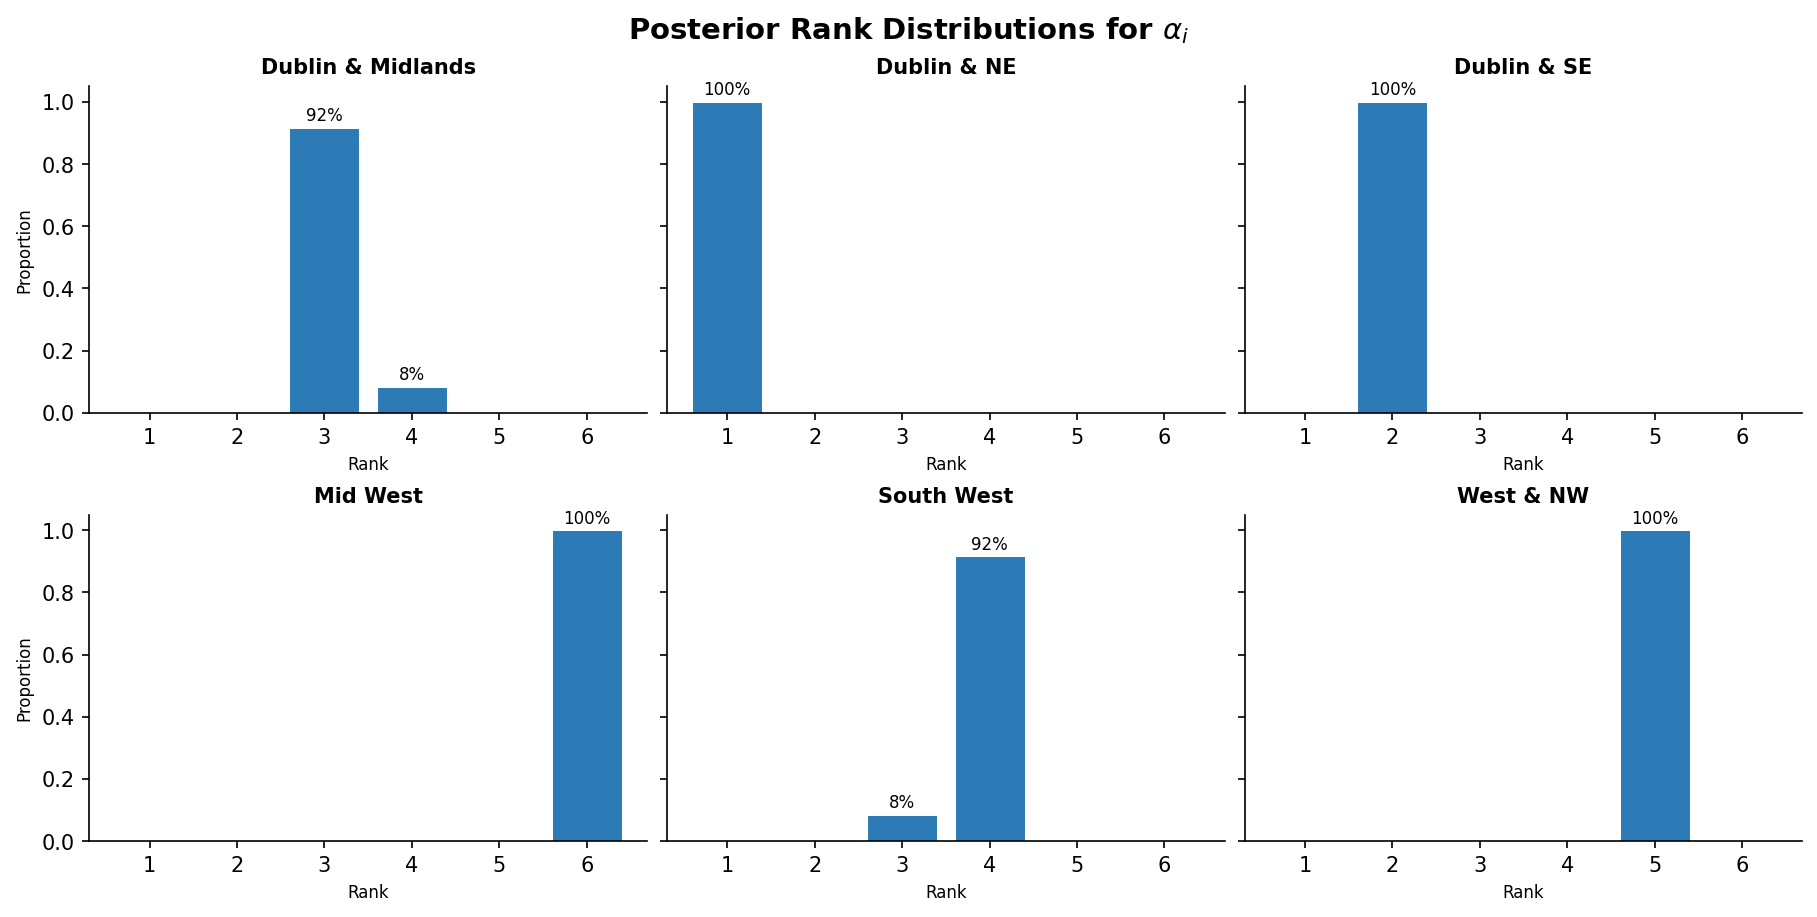

In [35]:
n_samples = len(ranked_alpha)
fig, axes = plt.subplots(2, 3, figsize=(12, 6), dpi=150, layout='constrained', sharey=True)

for ax, col in zip(axes.flatten(), ranked_alpha.columns):
    counts = ranked_alpha[col].value_counts().reindex(range(1, 7), fill_value=0)
    props = counts / n_samples

    bars = ax.bar(range(1, 7), props, color='#2c7bb6', edgecolor='white', linewidth=0.5)

    for bar, p in zip(bars, props):
        if p > 0.005:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{p:.0%}', ha='center', va='bottom', fontsize=8)

    ax.set_title(SHORT_NAMES.get(col, col), fontsize=10, fontweight='600')
    ax.set_xlabel('Rank', fontsize=8)
    ax.set_xticks(range(1, 7))
    ax.set_ylabel('Proportion' if ax in axes[:, 0] else '', fontsize=8)
    sns.despine(ax=ax)

fig.suptitle(r'Posterior Rank Distributions for $\alpha_i$', fontsize=14, fontweight='bold')
fig.savefig(PLOT_DIR + 'ranks.png', bbox_inches='tight', dpi=150)
plt.show()

### Pairwise comparison

In [36]:
pairwise_heatmap(pairwise_test_df, 
                 'P(diff > 0)',
                 'asdf',
                 PLOT_DIR + 'ranked_pairwise.png')

NameError: name 'pairwise_test_df' is not defined